<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HESQForce006.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Initialization cell
import numpy as np
import matplotlib.pyplot as plt

N = 100
x = np.linspace(0, 2*np.pi, N)

# Cluster: Gaussian bump
def gaussian_cluster(x, center, sigma, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * sigma**2))

cluster = gaussian_cluster(x, center=np.pi, sigma=0.3, amplitude=0.1)

# Perturbation: sinusoidal kick
omega = 1.0
epsilon = 0.01
kick = epsilon * np.sin(omega * x)

# Combined lattice
lattice = cluster + kick
history = [lattice.copy()]


In [2]:
# Propagation cell
def evolve_feedback(lattice, dt=0.1, threshold=0.02, feedback_strength=0.5):
    new = lattice.copy()
    for i in range(1, len(lattice)-1):
        interaction = lattice[i+1] - 2*lattice[i] + lattice[i-1]
        feedback = feedback_strength * lattice[i] if abs(lattice[i]) > threshold else 0
        new[i] += dt * (interaction + feedback)
    return new

for t in range(1000):
    lattice = evolve_feedback(lattice)
    if t % 50 == 0:
        history.append(lattice.copy())


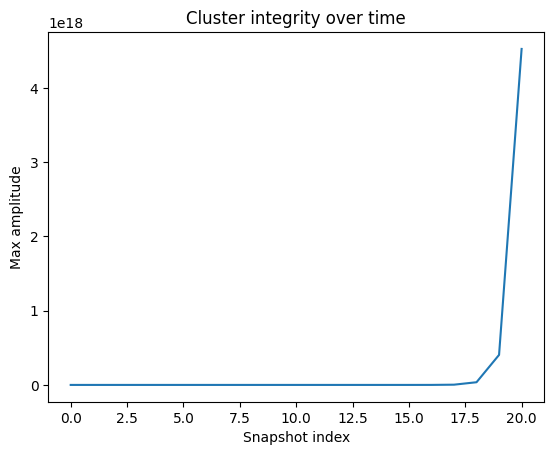

In [3]:
# Cluster integrity: amplitude concentration
integrity = [np.max(np.abs(h)) for h in history]

plt.plot(range(len(integrity)), integrity)
plt.xlabel("Snapshot index")
plt.ylabel("Max amplitude")
plt.title("Cluster integrity over time")
plt.show()


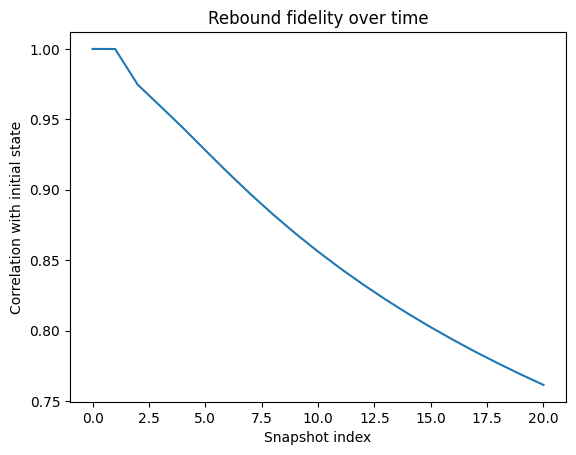

In [4]:
# Rebound fidelity: correlation with initial cluster
def correlation(a, b):
    return np.dot(a, b) / (np.linalg.norm(a)*np.linalg.norm(b))

fidelity = [correlation(history[0], h) for h in history]

plt.plot(range(len(fidelity)), fidelity)
plt.xlabel("Snapshot index")
plt.ylabel("Correlation with initial state")
plt.title("Rebound fidelity over time")
plt.show()


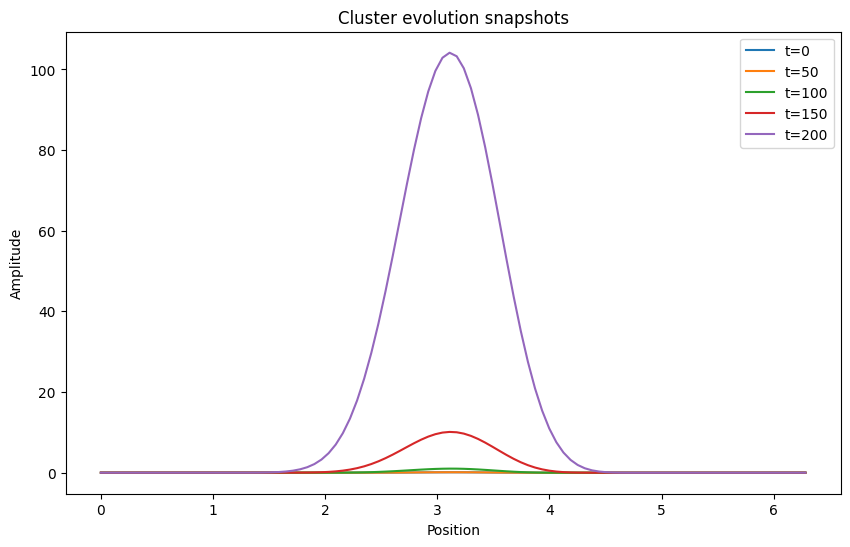

In [5]:
# Cluster snapshots
plt.figure(figsize=(10,6))
for idx, h in enumerate(history[:5]):
    plt.plot(x, h, label=f"t={idx*50}")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Cluster evolution snapshots")
plt.legend()
plt.show()
